<a href="https://colab.research.google.com/github/thunerous/MH/blob/main/%D0%9B%D0%A0_2_%D0%9C%D0%9D_%D0%A1i%D0%B4%D0%BE%D1%80%D1%86%D0%B5%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Завдання 1

In [1]:
from google.colab import files
import pandas as pd
import numpy as np

uploaded = files.upload()

Saving heart.csv to heart.csv


In [2]:
df = pd.read_csv( "heart.csv")

df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0.23
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0.37
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0.24
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0.28
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,0.85
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0.40
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0.15
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,0.82


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   float64
dtypes: float64(2), int64(12)
memory usage: 112.2 KB


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.536390
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.285822
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.260000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,0.710000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,0.810000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,0.900000


In [6]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [7]:
df.shape

(1025, 14)

In [8]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [9]:
df.duplicated().sum()

np.int64(55)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(970, 14)

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

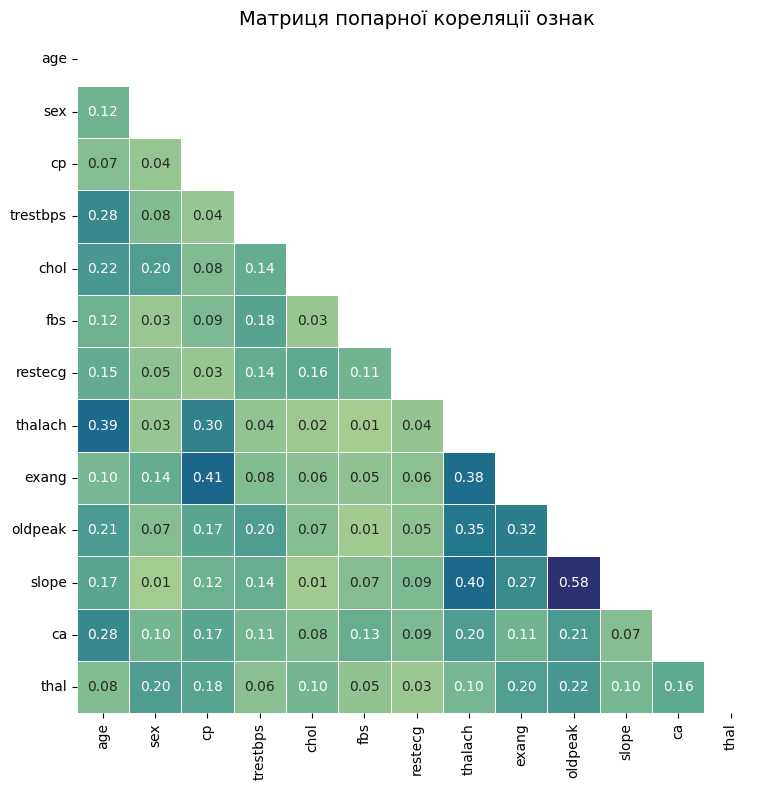

In [13]:
mtx = df.drop('target', axis=1).corr(numeric_only=True).abs()

# Побудова теплової карти кореляції
fig, ax = plt.subplots(figsize=(8, 8))

sns.heatmap(
    mtx,
    cmap='crest',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    mask=np.triu(np.ones_like(mtx, dtype=bool)),  # маскуємо верхній трикутник
    square=True,
    cbar=False,
    ax=ax
)

plt.title("Матриця попарної кореляції ознак", fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
corr_with_EVENT = df.corr()['target'].abs().sort_values(ascending=False)
corr_with_EVENT

,target
target,1.000000
cp,0.421743
exang,0.417985
oldpeak,0.395973
thalach,0.391855
ca,0.367250
thal,0.330854
slope,0.310289
sex,0.272580
age,0.209865


In [15]:
df['target'].value_counts()

,count
target,
0.83,30
0.80,30
0.85,30
0.78,29
0.86,29
0.89,28
0.88,27
0.82,27
0.72,25


In [16]:
df['trestbps'].value_counts()

,count
trestbps,
120,120
130,116
140,103
110,60
150,52
138,42
128,38
125,35
160,33


In [17]:
from sklearn.feature_selection import mutual_info_classif

In [18]:
# X — ознаки, y — цільова змінна
X = df.drop(columns=['target'])
y = df['target']

# Вказуємо дискретні (категоріальні) ознаки
discrete_features = X.columns.isin([
    'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'])

# Обчислення взаємної інформації
from sklearn.feature_selection import mutual_info_regression
mi_scores = mutual_info_regression(
    X, y,
    discrete_features=discrete_features,
    random_state=42
)

# Перетворення у pd.Series і сортування
mi_scores = pd.Series(
    mi_scores,
    name='MI Scores',
    index=X.columns
).sort_values()

# Виведення випадкових 5 ознак
print(mi_scores.sample(5))

thalach    0.063442
restecg    0.025986
age        0.019021
chol       0.074682
ca         0.123416
Name: MI Scores, dtype: float64


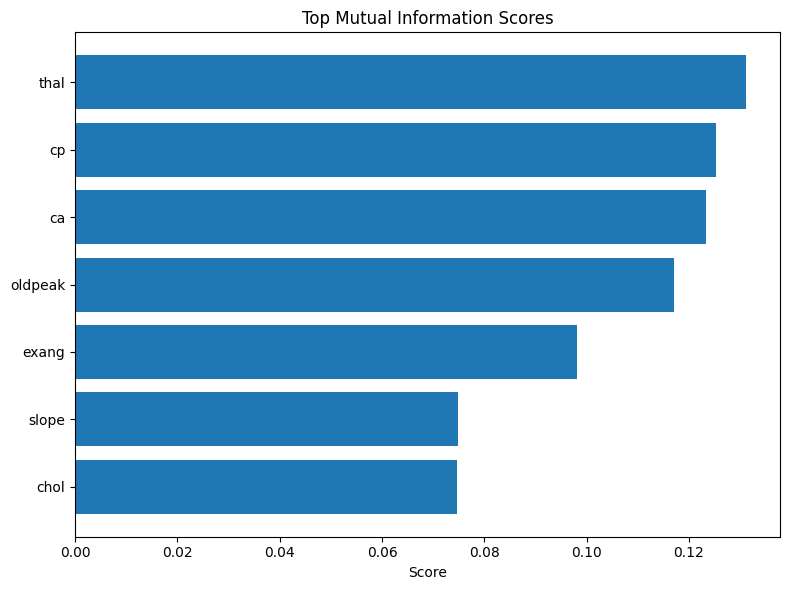

In [19]:
# Відфільтровуємо ненульові значення і сортуємо за спаданням
nonzero_mi_scores = mi_scores[mi_scores > 0].sort_values(ascending=False)

# Вибираємо топ-7
top_mi_scores = nonzero_mi_scores.head(7)

# Побудова горизонтального графіка
plt.figure(figsize=(8, 6))
plt.barh(top_mi_scores.index[::-1], top_mi_scores[::-1])  # інвертуємо порядок для найвищих зверху
plt.title('Top Mutual Information Scores')
plt.xlabel('Score')
plt.tight_layout()
plt.show()

Завдання 2https://www.kaggle.com/datasets/denkuznetz/taxi-price-prediction

In [30]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("denkuznetz/taxi-price-prediction")
#https://www.kaggle.com/datasets/denkuznetz/taxi-price-prediction
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'taxi-price-prediction' dataset.
Path to dataset files: /kaggle/input/taxi-price-prediction


In [31]:
df = pd.read_csv(os.path.join(path, "taxi_trip_pricing.csv"))

df

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [33]:
df['Time_of_Day'].value_counts()

,count
Time_of_Day,
Afternoon,371
Morning,283
Evening,203
Night,93


In [34]:
df['Day_of_Week'].value_counts()

,count
Day_of_Week,
Weekday,655
Weekend,295


In [35]:
df['Traffic_Conditions'].value_counts()

,count
Traffic_Conditions,
Low,397
Medium,371
High,182


In [36]:
df['Weather'].value_counts()

,count
Weather,
Clear,667
Rain,227
Snow,56


In [37]:
df['Traffic_Conditions'] = df['Traffic_Conditions'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

df['Weather'] = df['Weather'].map({
    'Clear': 0,
    'Rain': 1,
    'Snow': 2
})

df['Day_of_Week'] = df['Day_of_Week'].map({
    'Weekday': 0,
    'Weekend': 1
})

df['Time_of_Day'] = df['Time_of_Day'].map({
    'Morning': 0,
    'Afternoon': 1,
    'Evening': 2,
    'Night': 3
})

In [38]:
df

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,0.0,0.0,3.0,0.0,0.0,3.56,0.80,0.32,53.82,36.2624
1,47.59,1.0,0.0,1.0,2.0,0.0,NaN,0.62,0.43,40.57,NaN
2,36.87,2.0,1.0,1.0,2.0,0.0,2.70,1.21,0.15,37.27,52.9032
3,30.33,2.0,0.0,4.0,0.0,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,2.0,0.0,3.0,2.0,0.0,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,1.0,1.0,4.0,1.0,0.0,2.39,0.62,0.49,58.39,34.4049
996,45.95,3.0,0.0,4.0,1.0,0.0,3.12,0.61,NaN,61.96,62.1295
997,7.70,0.0,0.0,3.0,0.0,1.0,2.08,1.78,NaN,54.18,33.1236
998,47.56,0.0,0.0,1.0,0.0,0.0,2.67,0.82,0.17,114.94,61.2090


In [39]:
df.isnull().sum()

,0
Trip_Distance_km,50
Time_of_Day,50
Day_of_Week,50
Passenger_Count,50
Traffic_Conditions,50
Weather,50
Base_Fare,50
Per_Km_Rate,50
Per_Minute_Rate,50
Trip_Duration_Minutes,50


In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
df.fillna(df.mean(), inplace=True)

In [42]:
df.isnull().sum()

,0
Trip_Distance_km,0
Time_of_Day,0
Day_of_Week,0
Passenger_Count,0
Traffic_Conditions,0
Weather,0
Base_Fare,0
Per_Km_Rate,0
Per_Minute_Rate,0
Trip_Duration_Minutes,0


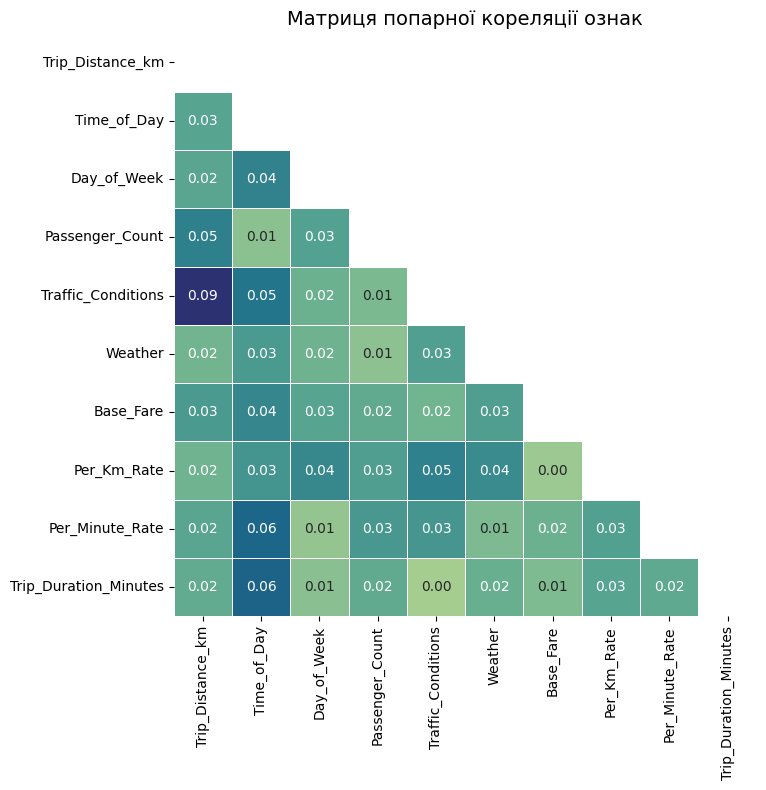

In [43]:
mtx = df.drop('Trip_Price', axis=1).corr(numeric_only=True).abs()

# Побудова теплової карти кореляції
fig, ax = plt.subplots(figsize=(8, 8))

sns.heatmap(
    mtx,
    cmap='crest',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    mask=np.triu(np.ones_like(mtx, dtype=bool)),  # маскуємо верхній трикутник
    square=True,
    cbar=False,
    ax=ax
)

plt.title("Матриця попарної кореляції ознак", fontsize=14)
plt.tight_layout()
plt.show()

In [44]:
from sklearn.feature_selection import mutual_info_regression

In [45]:
# X — ознаки, y — цільова змінна
X = df.drop(columns=['Trip_Price'])
y = df['Trip_Price']

# Вказуємо дискретні (категоріальні) ознаки
discrete_features = X.columns.isin([
    'Traffic_Conditions', 'Weather', 'Day_of_Week',
    'Time_of_Day'])

# Обчислення взаємної інформації
mi_scores = mutual_info_regression(
    X, y,
    discrete_features=discrete_features,
    random_state=42
)

# Перетворення у pd.Series і сортування
mi_scores = pd.Series(
    mi_scores,
    name='MI Scores',
    index=X.columns
).sort_values()

# Виведення випадкових 5 ознак
print(mi_scores.sample(5))

Base_Fare           0.000000
Day_of_Week         0.000000
Trip_Distance_km    0.395027
Per_Km_Rate         0.133017
Weather             0.000000
Name: MI Scores, dtype: float64


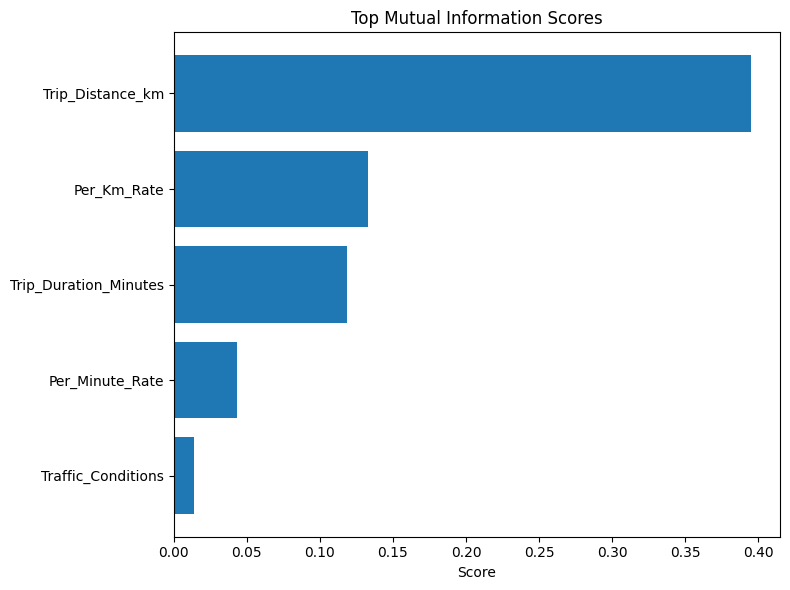

In [46]:
# Відфільтровуємо ненульові значення і сортуємо за спаданням
nonzero_mi_scores = mi_scores[mi_scores > 0].sort_values(ascending=False)

# Вибираємо топ-5
top_mi_scores = nonzero_mi_scores.head()

# Побудова горизонтального графіка
plt.figure(figsize=(8, 6))
plt.barh(top_mi_scores.index[::-1], top_mi_scores[::-1])  # інвертуємо порядок для найвищих зверху
plt.title('Top Mutual Information Scores')
plt.xlabel('Score')
plt.tight_layout()
plt.show()

Висновок
У ході виконання лабораторної роботи було освоєно основи аналізу даних за допомогою бібліотек Pandas, Matplotlib та Seaborn у середовищі Google Colab. Було виконано завантаження та обробку набору даних про гриби, що містить їх характеристики та класифікацію на їстівні та отруйні . Проведено первинний аналіз даних, побудовано візуалізації та зроблено висновки щодо структури та особливостей датасету. Отримані навички дозволяють ефективно працювати з реальними даними та застосовувати методи аналізу для вирішення практичних задач.